# Depth-First Search

**Domain:** `data-structures-algorithms`

Picture yourself exploring a cave system with a single ball of string. You
walk into the first tunnel you see, and when that tunnel forks, you take
the first fork, and when *that* forks, you take the first fork again — you
keep going **as deep as you possibly can**, always committing to one new
passage at a time. You only turn back when you hit a dead end (a chamber
with no unexplored tunnels leading out of it), and when you do, you back up
to the most recent fork that still has an unexplored option and try that
instead. You never revisit a tunnel you've already explored.

That's **depth-first search (DFS)**: from a starting point, plunge into one
unvisited neighbor, then one of *its* unvisited neighbors, and so on, only
backtracking when you run out of new places to go from where you are.

Contrast this with **breadth-first search (BFS)**, which explores like a
cautious search party: check every tunnel directly connected to your
starting chamber first, *then* every tunnel one step further out, then two
steps further out — expanding outward in rings rather than plunging down
one path. BFS always finds the *shortest* route to somewhere (in an
unweighted maze); DFS makes no such promise — it might stumble down a long,
winding tunnel to reach a spot that had a two-step shortcut it never
considered, because it committed to depth over breadth. Both are legitimate
answers to "how do I visit everything reachable from here" — they just
trade off *which* things they find first.

After this tutorial you'll be able to:

- Trace DFS by hand on a small graph and predict its visit order.
- Implement DFS two ways — recursively, and iteratively with an explicit
  stack — and know why production code often prefers the second.
- Read and derive the classic discover/finish-time bookkeeping DFS uses,
  and use it to classify every edge in a graph as a tree, back, forward, or
  cross edge.
- Explain *why* a back edge in a directed graph proves a cycle exists —
  the fact that makes DFS the standard cycle-detection algorithm.
- Know when DFS is the wrong tool (shortest paths) and when it's exactly
  right (cycle detection, topological sort, connected components, maze
  solving).


## The idea, intuitively

**The rule is simple: from wherever you are, go to an unvisited neighbor
immediately. Only look for a different option once you're completely stuck.**
Mark every place you visit so you never walk the same tunnel twice (without
that, a loop in the graph would trap you forever).

Let's trace it on a small graph — 7 nodes, no cycles yet (we'll add one
later once discover/finish times are on the table):

```
A -> B, C
B -> D, E
C -> F
E -> G
```

Starting at `A`, DFS commits to the *first* neighbor in each node's list
and dives:


In [1]:
# A tiny adjacency-list graph, exactly like you'd sketch it on paper.
graph = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F"],
    "D": [],
    "E": ["G"],
    "F": [],
    "G": [],
}

def dfs_recursive(graph, node, visited=None, order=None, depth=0):
    if visited is None:
        visited, order = set(), []
    visited.add(node)
    order.append(node)
    print(f"{'  ' * depth}visit {node}  (call stack depth {depth})")
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs_recursive(graph, neighbor, visited, order, depth + 1)
    return order

visit_order = dfs_recursive(graph, "A")
print("\nvisit order:", visit_order)

visit A  (call stack depth 0)
  visit B  (call stack depth 1)
    visit D  (call stack depth 2)
    visit E  (call stack depth 2)
      visit G  (call stack depth 3)
  visit C  (call stack depth 1)
    visit F  (call stack depth 2)

visit order: ['A', 'B', 'D', 'E', 'G', 'C', 'F']


Watch the indentation in the printed trace: it *is* the call stack. Every
time DFS commits to a neighbor, that's a new recursive call sitting on top
of the previous one — Python's own call stack is doing the "keep a mental
note of where to backtrack to" bookkeeping for us. `A` calls into `B`, which
calls into `D` (a dead end — no neighbors, so it returns immediately),
which pops back to `B`, which then calls into `E`, which calls into `G`
(another dead end), which pops all the way back to `A`, which finally tries
its second neighbor, `C`, which calls into `F`.

**Takeaway:** DFS visit order is exactly what you get by always expanding
the most recently discovered unvisited node first — which is precisely
what a stack (last-in, first-out) gives you, whether that stack is Python's
own call stack (recursive version) or one you manage by hand (iterative
version, next).


In [2]:
# The exact same traversal, but with an explicit stack instead of recursion.
# This is the version production code often prefers -- see "Limitations" later
# for why (recursive DFS can blow the call stack on deep graphs; this can't).
def dfs_iterative(graph, start):
    visited = set()
    order = []
    stack = [start]
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        print(f"visit {node}  (explicit stack now: {list(stack)})")
        # Push neighbors in reverse so the *first* neighbor in the adjacency
        # list is the one popped (explored) next -- matching the recursive
        # version's left-to-right order.
        for neighbor in reversed(graph[node]):
            if neighbor not in visited:
                stack.append(neighbor)
    return order

iterative_order = dfs_iterative(graph, "A")
print("\nvisit order:", iterative_order)
assert iterative_order == visit_order, "recursive and iterative should agree"
print("matches recursive order:", iterative_order == visit_order)

visit A  (explicit stack now: [])
visit B  (explicit stack now: ['C'])
visit D  (explicit stack now: ['C', 'E'])
visit E  (explicit stack now: ['C'])
visit G  (explicit stack now: ['C'])
visit C  (explicit stack now: [])
visit F  (explicit stack now: [])

visit order: ['A', 'B', 'D', 'E', 'G', 'C', 'F']
matches recursive order: True


Same order, two mechanisms. The recursive version *is* using a stack — it's
just the language runtime's call stack instead of a Python list you can see.
That equivalence is exact, not approximate, and it's the key to everything
that follows: DFS is "stack-order graph exploration," full stop, and once
you see that, both implementations are the same algorithm wearing different
clothes.

> **Note on this toy example's `visited` set:** it prevents infinite loops
> on graphs with cycles, but it throws away information — specifically,
> *when* each node was entered and left. The next section puts that
> information back, because it's what turns "did I visit this" into
> "how does this edge relate to the ones I've already seen" — the basis of
> cycle detection.


## Going deeper: the formal definition

### Discover and finish times

Instead of a boolean `visited`/`unvisited`, CLRS's treatment (Cormen,
Leiserson, Rivest & Stein, *Introduction to Algorithms*, Ch. 22) gives every
vertex three **colors** and two **timestamps**, driven by a single global
clock that ticks once per event:

- **white** — not yet discovered.
- **gray** — discovered, currently "open" (on the DFS call stack; some
  descendant may still be unexplored).
- **black** — finished: every vertex reachable from it via still-white
  paths has been fully explored.

$$
\text{discover}[u] = \text{the clock value when } u \text{ turns white} \to \text{gray}
$$
$$
\text{finish}[u] = \text{the clock value when } u \text{ turns gray} \to \text{black}
$$

The clock increments by 1 at every discover *and* every finish event, so for
$n$ vertices the timestamps used are exactly $1, 2, \dots, 2n$ — every
vertex owns one discover tick and one finish tick, and
$1 \le \text{discover}[u] < \text{finish}[u] \le 2n$ for every $u$.

### The parenthesis theorem

Think of each vertex's lifetime as an interval $(\text{discover}[u],
\text{finish}[u])$ — literally write `(` when `u` is discovered and `)`
when it finishes, in timestamp order. For any two vertices $u, v$, exactly
one of three things is true:

1. The intervals are **disjoint**: $\text{finish}[u] < \text{discover}[v]$
   or $\text{finish}[v] < \text{discover}[u]$ — neither is an ancestor of
   the other in the DFS forest.
2. The intervals are **nested**: $[\text{discover}[u], \text{finish}[u]]$
   entirely contains $[\text{discover}[v], \text{finish}[v]]$ (or vice
   versa) — one is a descendant of the other.
3. They can **never partially overlap** — you will never see
   $\text{discover}[u] < \text{discover}[v] < \text{finish}[u] <
   \text{finish}[v]$.

**Proof sketch.** Suppose (WLOG) $\text{discover}[u] < \text{discover}[v]$.
Case A: $v$ is discovered *while $u$ is still gray* (i.e.
$\text{discover}[v] < \text{finish}[u]$). Because DFS only finishes $u$
after every vertex reachable from $u$ through white edges has been fully
explored, and $v$ became reachable-and-white exactly when it was found
during $u$'s exploration, $v$'s entire subtree call — discover through
finish — happens strictly *inside* $u$'s still-open call. So
$\text{finish}[v] < \text{finish}[u]$: nested. Case B: $v$ is discovered
*after* $u$ has already finished ($\text{discover}[v] \ge
\text{finish}[u]$). Then $u$'s interval already closed before $v$'s opened:
disjoint. Partial overlap would require $v$ to start inside $u$'s interval
but finish outside it — but that means $u$ finished while $v$ was still
gray, which is impossible: DFS never marks a vertex black while a vertex it
discovered is still open. $\blacksquare$

This is a clean structural guarantee, not a coincidence — it's *why* the
discover/finish timestamps alone are enough to reconstruct the entire
ancestor/descendant structure of the DFS forest, which is exactly what edge
classification below relies on.

### Time complexity: $O(V + E)$

Recursive DFS calls `visit(u)` exactly once per vertex — a vertex only
turns white $\to$ gray once, and `visit` is only invoked on white vertices —
so the "per-vertex" work (color/timestamp bookkeeping) is $O(V)$ total.
Inside `visit(u)`, the `for` loop walks every entry in `u`'s adjacency
list. Summed over all vertices, that's $\sum_u \deg(u)$, which counts every
directed edge exactly once (or every undirected edge exactly twice) — i.e.
$O(E)$. Total: $O(V) + O(E) = O(V + E)$, **linear in the size of the graph**
— DFS looks at every vertex and every edge a constant number of times and
nothing more.

### Edge classification

While exploring edge $(u, v)$ from a gray vertex $u$, the color of $v$ (plus,
for directed graphs, a discover-time comparison) tells you exactly what kind
of edge it is:

| Edge type  | Condition when $(u,v)$ is examined                          | Meaning |
|------------|---------------------------------------------------------------|---------|
| **Tree**   | $v$ is white                                                   | $(u,v)$ is used to first discover $v$ — becomes an edge of the DFS forest. |
| **Back**   | $v$ is gray                                                     | $v$ is an ancestor of $u$ on the current stack. |
| **Forward**| $v$ is black **and** $\text{discover}[u] < \text{discover}[v]$ | $v$ is a descendant of $u$, already finished by the time $u$ re-examines it. |
| **Cross**  | $v$ is black **and** $\text{discover}[u] > \text{discover}[v]$ | $v$ is in an already-finished, unrelated subtree — no ancestor/descendant relation to $u$. |

(Undirected graphs never produce forward or cross edges — the parenthesis
theorem plus the fact that every undirected edge is examined from *both*
endpoints forces every non-tree edge to show up as a back edge from one
side, so DFS on an undirected graph only ever needs the tree/back cases.)

### Why a back edge means a cycle exists

This is the fact that makes DFS *the* standard cycle-detection algorithm,
so it's worth proving, not just asserting.

**Claim.** A directed graph has a cycle if and only if a DFS over it finds
a back edge.

**($\Leftarrow$) A back edge implies a cycle.** Suppose DFS examines edge
$(u, v)$ and finds $v$ gray. Gray means $v$ is still on the DFS call stack
— i.e. $v$ is an ancestor of $u$ in the DFS tree, so there is a tree path
$v \to \cdots \to u$ made entirely of tree edges (each one discovered $v$'s
descendant while $v$ was still open). The edge $(u, v)$ closes that path
into a cycle: $v \to \cdots \to u \to v$. So a back edge is a witness you
can point to directly.

**($\Rightarrow$) A cycle implies a back edge.** Suppose the graph has a
cycle $v_0 \to v_1 \to \cdots \to v_k \to v_0$. Let $v_i$ be whichever
vertex on this cycle DFS discovers *first* (the earliest discover time
among $v_0, \ldots, v_k$). At the moment $v_i$ is discovered, every other
vertex on the cycle is still white (by choice of $v_i$ as earliest), so
$v_i$'s exploration will eventually reach every vertex on the cycle — in
particular it will reach $v_{i-1}$ (the cycle's predecessor of $v_i$,
indices mod $k+1$) via a path of still-white vertices, which the DFS
explores as tree edges, all while $v_i$ remains gray (open) the entire
time, since $v_i$ can't finish until everything reachable from it through
white paths is explored, and $v_{i-1}$ is one such vertex. So when DFS
examines the edge $(v_{i-1}, v_i)$, $v_i$ is still gray: that's a back edge.
$\blacksquare$

This is exactly why the Java implementation below reports "cycle found"
if and only if it records at least one `BACK` edge — no separate cycle-
checking pass is needed; it falls straight out of the coloring DFS already
does.


## Visuals

The reference implementation lives in
[`src/DFS.java`](src/DFS.java) — real Java, using an adjacency-list
representation, implementing **both** the recursive and explicit-stack
iterative versions from scratch, instrumented to report discover/finish
times and to classify every edge exactly as defined above. It reads a
graph from stdin (`V E directed start` followed by `E` edge lines) and
prints the traversal order, discover/finish times, per-edge classification,
and whether a cycle (a back edge) was found — for *both* variants, so we
can confirm they agree.

We compile it with `javac` and run the real compiled program via
`subprocess` — every number and every plot below comes from that real
execution, not a hand-simulated stand-in.

Here's a small 6-vertex directed graph engineered to contain all four edge
types in one run:

```
0 -> 1, 3
1 -> 4
2 -> 4, 5
3 -> 1
4 -> 3
```


In [3]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
class_file = src_dir / "DFS.class"

compile_cmd = ["javac", str(src_dir / "DFS.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", class_file)

compile return code: 0
compiled successfully -> src\DFS.class


In [4]:
def run_dfs(V, edges, directed, start, mode="both"):
    # Run the real compiled DFS.class on a graph, return the parsed stdout.
    lines = [f"{V} {len(edges)} {1 if directed else 0} {start}"]
    lines += [f"{u} {v}" for u, v in edges]
    input_str = "\n".join(lines)
    proc = subprocess.run(
        ["java", "-cp", "src", "DFS", mode],
        input=input_str, capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr
    return proc.stdout

def parse_dfs_output(text):
    # Parse DFS.java's line-oriented output into one dict per variant
    # ("RECURSIVE DFS" / "ITERATIVE DFS (explicit stack)").
    sections = {}
    current = None
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("---"):
            current = line.strip("- ").strip()
            sections[current] = {"order": [], "discover": {}, "finish": {}, "edges": [], "cycle": None}
        elif line.startswith("ORDER:"):
            sections[current]["order"] = [int(x) for x in line[len("ORDER:"):].split()]
        elif line.startswith("DISCOVER:"):
            for pair in line[len("DISCOVER:"):].split():
                k, v = pair.split("=")
                sections[current]["discover"][int(k)] = int(v)
        elif line.startswith("FINISH:"):
            for pair in line[len("FINISH:"):].split():
                k, v = pair.split("=")
                sections[current]["finish"][int(k)] = int(v)
        elif line.startswith("EDGE"):
            _, u, v, kind = line.split()
            sections[current]["edges"].append((int(u), int(v), kind))
        elif line.startswith("CYCLE:"):
            sections[current]["cycle"] = line.split(":")[1].strip() == "true"
    return sections

demo_V = 6
demo_edges = [(0, 1), (0, 3), (1, 4), (4, 3), (3, 1), (2, 4), (2, 5)]
demo_start = 0

raw_output = run_dfs(demo_V, demo_edges, directed=True, start=demo_start)
print(raw_output)

parsed = parse_dfs_output(raw_output)
recursive = parsed["RECURSIVE DFS"]
iterative = parsed["ITERATIVE DFS (explicit stack)"]

assert recursive["order"] == iterative["order"]
assert recursive["discover"] == iterative["discover"]
assert recursive["finish"] == iterative["finish"]
assert set(recursive["edges"]) == set(iterative["edges"])
assert recursive["cycle"] == iterative["cycle"] == True
print("\nrecursive and iterative DFS agree exactly on order, timestamps, edges, and cycle detection.")

GRAPH vertices=6 directed=true start=0
--- RECURSIVE DFS ---
ORDER: 0 1 4 3 2 5
DISCOVER: 0=1 1=2 2=9 3=4 4=3 5=10
FINISH: 0=8 1=7 2=12 3=5 4=6 5=11
EDGE 0 1 TREE
EDGE 1 4 TREE
EDGE 4 3 TREE
EDGE 3 1 BACK
EDGE 0 3 FORWARD
EDGE 2 4 CROSS
EDGE 2 5 TREE
CYCLE: true
--- ITERATIVE DFS (explicit stack) ---
ORDER: 0 1 4 3 2 5
DISCOVER: 0=1 1=2 2=9 3=4 4=3 5=10
FINISH: 0=8 1=7 2=12 3=5 4=6 5=11
EDGE 0 1 TREE
EDGE 1 4 TREE
EDGE 4 3 TREE
EDGE 3 1 BACK
EDGE 0 3 FORWARD
EDGE 2 4 CROSS
EDGE 2 5 TREE
CYCLE: true


recursive and iterative DFS agree exactly on order, timestamps, edges, and cycle detection.


Both variants produced identical discover/finish times and identical edge
classifications, confirming the "same algorithm, different mechanism"
claim from the intuitive section — now backed by a real compiled program
instead of a toy Python example.

### The graph, colored by real DFS edge classification


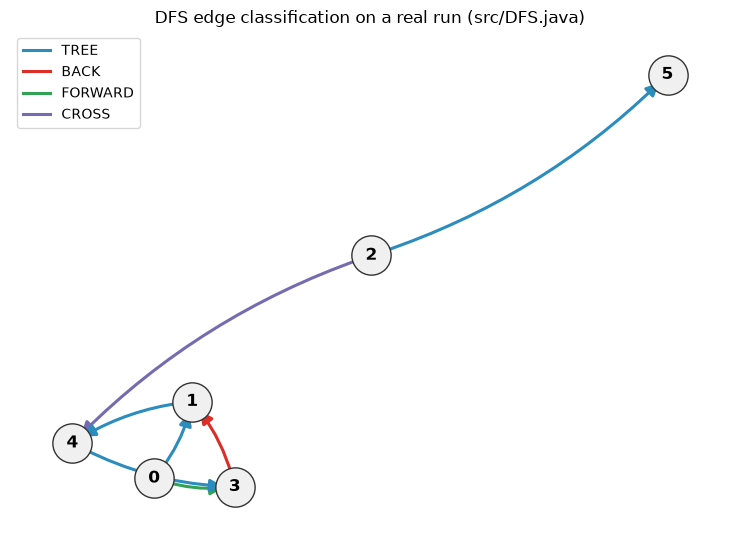

edge classifications from the real run:
  0 -> 1: TREE
  1 -> 4: TREE
  4 -> 3: TREE
  3 -> 1: BACK
  0 -> 3: FORWARD
  2 -> 4: CROSS
  2 -> 5: TREE


In [5]:
import matplotlib.pyplot as plt
import networkx as nx

edge_colors = {"TREE": "#2b8cbe", "BACK": "#de2d26", "FORWARD": "#31a354", "CROSS": "#756bb1"}

G = nx.DiGraph()
G.add_nodes_from(range(demo_V))
G.add_edges_from([(u, v) for u, v, _ in recursive["edges"]])

pos = nx.spring_layout(G, seed=7)
fig, ax = plt.subplots(figsize=(7.5, 5.5))

nx.draw_networkx_nodes(G, pos, node_color="#f0f0f0", edgecolors="#333333", node_size=800, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax, font_weight="bold")

for kind in ["CROSS", "FORWARD", "BACK", "TREE"]:  # draw tree edges last (on top)
    edges_of_kind = [(u, v) for u, v, k in recursive["edges"] if k == kind]
    nx.draw_networkx_edges(
        G, pos, edgelist=edges_of_kind, ax=ax,
        edge_color=edge_colors[kind], width=2.2, arrowsize=18,
        connectionstyle="arc3,rad=0.12", label=kind,
    )

handles = [plt.Line2D([0], [0], color=c, lw=2.2, label=k) for k, c in edge_colors.items()]
ax.legend(handles=handles, loc="upper left", frameon=True)
ax.set_title("DFS edge classification on a real run (src/DFS.java)")
ax.axis("off")
plt.tight_layout()
plt.show()

print("edge classifications from the real run:")
for u, v, kind in recursive["edges"]:
    print(f"  {u} -> {v}: {kind}")

Vertex 3's edge back to vertex 1 is the **BACK** edge — 1 is 3's ancestor
on the DFS stack (`0 -> 1 -> 4 -> 3`), so this closes the cycle
`1 -> 4 -> 3 -> 1`, exactly matching the "back edge implies cycle" proof
above. Edge `0 -> 3` is **FORWARD** (3 is a descendant of 0, already
finished by the time 0 re-examines it), and `2 -> 4` is **CROSS** (4 sits in
an already-finished, unrelated subtree relative to 2).

### Discover/finish timeline — the parenthesis theorem, visually


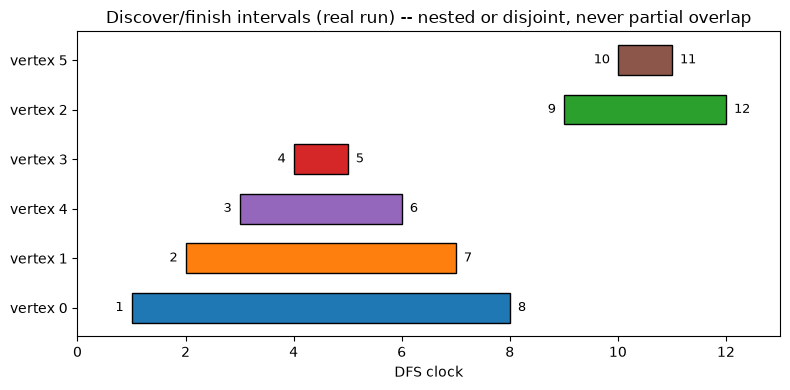

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

order_by_discover = sorted(range(demo_V), key=lambda u: recursive["discover"][u])
colors = plt.cm.tab10.colors

for row, u in enumerate(order_by_discover):
    d, f = recursive["discover"][u], recursive["finish"][u]
    ax.barh(row, f - d, left=d, height=0.6, color=colors[u % len(colors)], edgecolor="black")
    ax.text(d - 0.15, row, str(d), ha="right", va="center", fontsize=9)
    ax.text(f + 0.15, row, str(f), ha="left", va="center", fontsize=9)

ax.set_yticks(range(demo_V))
ax.set_yticklabels([f"vertex {u}" for u in order_by_discover])
ax.set_xlabel("DFS clock")
ax.set_title("Discover/finish intervals (real run) -- nested or disjoint, never partial overlap")
ax.set_xlim(0, 2 * demo_V + 1)
plt.tight_layout()
plt.show()

Read the bars left to right: vertex 0's interval `[1, 8]` fully contains
vertex 1's `[2, 7]`, which fully contains vertex 4's `[3, 6]`, which fully
contains vertex 3's `[4, 5]` — a clean nested chain, exactly the DFS tree
path `0 -> 1 -> 4 -> 3`. Vertex 2's interval `[9, 12]` starts only after
vertex 0's has already closed at `8` — disjoint, because 2 is a separate
DFS tree root with no ancestor/descendant relationship to 0. No bar ever
starts inside another and ends outside it. That is the parenthesis theorem,
holding on a real run instead of just on paper.


## Implementation

Beyond the demo graph above, two more real runs are worth checking: a
directed acyclic graph (should report no cycle), and the deliberately deep
input used in "Limitations" below.


In [7]:
# A directed *acyclic* graph -- a small build-dependency graph, e.g.
# 0=compile, 1=link, 2=test, 3=package, 4=deploy, with no circular dependency.
dag_edges = [(0, 1), (1, 2), (1, 3), (2, 3), (3, 4)]
dag_output = run_dfs(V=5, edges=dag_edges, directed=True, start=0)
dag_parsed = parse_dfs_output(dag_output)
print(dag_output)
print("cycle found:", dag_parsed["RECURSIVE DFS"]["cycle"])
assert dag_parsed["RECURSIVE DFS"]["cycle"] is False
assert dag_parsed["ITERATIVE DFS (explicit stack)"]["cycle"] is False

GRAPH vertices=5 directed=true start=0
--- RECURSIVE DFS ---
ORDER: 0 1 2 3 4
DISCOVER: 0=1 1=2 2=3 3=4 4=5
FINISH: 0=10 1=9 2=8 3=7 4=6
EDGE 0 1 TREE
EDGE 1 2 TREE
EDGE 2 3 TREE
EDGE 3 4 TREE
EDGE 1 3 FORWARD
CYCLE: false
--- ITERATIVE DFS (explicit stack) ---
ORDER: 0 1 2 3 4
DISCOVER: 0=1 1=2 2=3 3=4 4=5
FINISH: 0=10 1=9 2=8 3=7 4=6
EDGE 0 1 TREE
EDGE 1 2 TREE
EDGE 2 3 TREE
EDGE 3 4 TREE
EDGE 1 3 FORWARD
CYCLE: false

cycle found: False


No back edges, no cycle — exactly what you'd want a build system to confirm
before trusting a dependency graph enough to compile it.


## Use cases

- **Cycle detection.** Build systems (Make, Bazel, npm/Cargo dependency
  resolution) run DFS over the "depends on" graph and reject it if a back
  edge shows up — a circular dependency, which the proof above guarantees
  exists whenever DFS reports one.
- **Topological sorting.** Running DFS to completion and reading off
  vertices in *reverse finish-time order* produces a valid topological
  sort of a DAG (this only works because of the parenthesis theorem: an
  edge $u \to v$ always means $u$ finishes after $v$ unless $v$ is a
  descendant of $u$, in which case it's a tree/forward edge and $u$ still
  finishes after it). This repository may cover topological sort as its
  own tutorial, built directly on this DFS implementation.
- **Connected components / strongly connected components.** Repeatedly
  running DFS from any unvisited vertex and grouping vertices by which run
  discovered them finds connected components in undirected graphs;
  Tarjan's and Kosaraju's algorithms extend this with extra bookkeeping to
  find **strongly connected components** in directed graphs.
- **Maze and puzzle solving.** The maze analogy from the intro is not just
  a teaching device — DFS (often randomized) is a standard way to both
  *generate* mazes (carve passages via DFS over a grid) and *solve* them.
- **Articulation points and bridges.** A single DFS pass, extended with a
  "lowest reachable discover time via one back edge" computation per
  vertex, finds articulation points (vertices whose removal disconnects
  the graph) and bridges (edges whose removal does) in $O(V+E)$ — useful
  for finding single points of failure in a network. This tutorial doesn't
  derive that extension, just flags it as a natural next step from the
  discover-time machinery already built here.


## Limitations & debates

**Recursive DFS can really stack-overflow — this isn't theoretical.** Each
recursive call is a real stack frame, and the JVM's default thread stack
(a few hundred KB to ~1MB) only holds so many. Let's actually trigger it: a
graph that's just one long chain of 200,000 vertices (`0 -> 1 -> 2 -> ...`)
forces DFS to recurse 200,000 levels deep before the first `finish` event.


In [8]:
def make_chain_input(n):
    lines = [f"{n} {n - 1} 1 0"] + [f"{i} {i + 1}" for i in range(n - 1)]
    return "\n".join(lines)

n = 200_000
chain_input = make_chain_input(n)

recursive_proc = subprocess.run(
    ["java", "-cp", "src", "DFS", "recursive"],
    input=chain_input, capture_output=True, text=True,
)
print("recursive DFS on a", n, "-vertex chain:")
print("  return code:", recursive_proc.returncode)
print("  first line of stderr:", recursive_proc.stderr.strip().splitlines()[0] if recursive_proc.stderr else "(none)")

iterative_proc = subprocess.run(
    ["java", "-cp", "src", "DFS", "iterative"],
    input=chain_input, capture_output=True, text=True,
)
iterative_parsed = parse_dfs_output(iterative_proc.stdout)
print("\niterative DFS on the same chain:")
print("  return code:", iterative_proc.returncode)
print("  vertices visited:", len(iterative_parsed["ITERATIVE DFS (explicit stack)"]["order"]))
print("  cycle found:", iterative_parsed["ITERATIVE DFS (explicit stack)"]["cycle"])

assert recursive_proc.returncode != 0 and "StackOverflowError" in recursive_proc.stderr
assert iterative_proc.returncode == 0
assert len(iterative_parsed["ITERATIVE DFS (explicit stack)"]["order"]) == n

recursive DFS on a 200000 -vertex chain:
  return code: 1
  first line of stderr: Exception in thread "main" java.lang.StackOverflowError



iterative DFS on the same chain:
  return code: 0
  vertices visited: 200000
  cycle found: False


The recursive version really does crash with a real `StackOverflowError` on
this input — not a simulated failure. The iterative version, with its
explicit `ArrayDeque<Frame>` living on the heap instead of the call stack,
visits all 200,000 vertices without issue. **This is exactly why production
graph code (compilers' dependency resolvers, large-scale graph databases)
often reaches for the iterative form despite the recursive form reading
more naturally** — recursive DFS is a fine default on graphs you know are
shallow or bounded, but it's a latent crash risk on graphs whose depth you
don't control (e.g. user-supplied data).

**DFS does not find shortest paths, and defaulting to it because it's
easier to write recursively is a real mistake people make.** DFS commits
to depth immediately, so the *first* time it reaches a given vertex is not
guaranteed to be via the shortest route — it might tunnel down a long
detour before a two-hop path ever gets considered, because that two-hop
path's other branch simply wasn't explored first. BFS, which expands
outward ring by ring, *does* guarantee the first time it reaches a vertex
is via a shortest path (in an unweighted graph) — that guarantee comes
directly from BFS's level-by-level order, which DFS's stack-order
traversal does not have and cannot be patched to have without changing the
algorithm into something that isn't DFS anymore. **Pick the traversal that
answers your actual question** — "is everything reachable / is there a
cycle / topological order" is DFS's home turf; "what's the shortest
unweighted path" is BFS's (or Dijkstra's, weighted).

**The DFS forest and edge classification depend on visit order.** Which
neighbor is "first" in each adjacency list, and which unvisited vertex is
picked next when a component finishes, changes which edges land in the
tree vs. get classified as forward/back/cross (though *whether* a cycle
exists — some back edge showing up somewhere — does not depend on this;
that's a structural graph property, not an artifact of traversal order).
Don't read too much into "this specific edge is a cross edge" as some deep
graph property; it's a property of this DFS run's choices, not of the graph
alone.


## References

- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 22 — the discover/finish-time framework, the
  parenthesis theorem, and edge classification used throughout this
  tutorial follow this treatment directly.
- Hopcroft, J. & Tarjan, R. *Efficient Algorithms for Graph Manipulation*,
  Communications of the ACM, 1973 — the foundational paper establishing
  DFS as an $O(V+E)$ technique for connectivity, biconnectivity, and planarity.
- Tarjan, R. *Depth-First Search and Linear Graph Algorithms*, SIAM Journal
  on Computing, 1972 — Tarjan's strongly-connected-components algorithm, a
  direct extension of the discover-time DFS built here.
- `src/DFS.java` in this tutorial's folder — the real, compiled
  implementation used for every measurement and diagram above.
